In [1]:
# Cell 1 — Env vars and imports
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

print("Imports OK.")

Imports OK.


In [2]:
# Cell 2 — Simulate CMOB-style multi-omics dataset
# Mirrors real CMOB structure: 4 omics blocks, 5 cancer subtypes, ~10% missing values
def simulate_cmob(
    n_patients=300,
    n_mrna=200, n_mirna=50, n_methy=200, n_cnv=200,
    n_classes=5, missing_rate=0.1, seed=42
):
    rng = np.random.default_rng(seed)
    labels = rng.integers(0, n_classes, size=n_patients)

    blocks = []
    for block_size in [n_mrna, n_mirna, n_methy, n_cnv]:
        block = rng.standard_normal((n_patients, block_size))
        for c in range(n_classes):
            mask = labels == c
            shift = rng.standard_normal(block_size) * 1.5
            block[mask] += shift
        blocks.append(block)

    X = np.concatenate(blocks, axis=1)

    # Introduce realistic missing values
    miss_idx = rng.random(X.shape) < missing_rate
    X[miss_idx] = np.nan

    col_names = (
        [f"mRNA_{i}"  for i in range(n_mrna)]  +
        [f"miRNA_{i}" for i in range(n_mirna)] +
        [f"Methy_{i}" for i in range(n_methy)] +
        [f"CNV_{i}"   for i in range(n_cnv)]
    )

    df = pd.DataFrame(X, columns=col_names)
    df["cancer_type"] = labels
    return df

df = simulate_cmob()
print(f"Shape        : {df.shape}")
print(f"Cancer types : {df['cancer_type'].value_counts().to_dict()}")
print(f"Missing vals : {df.isna().sum().sum()} ({df.isna().mean().mean()*100:.1f}%)")
df.head(3)

Shape        : (300, 651)
Cancer types : {2: 76, 3: 71, 0: 59, 1: 48, 4: 46}
Missing vals : 19462 (10.0%)


,mRNA_0,mRNA_1,mRNA_2,mRNA_3,mRNA_4,mRNA_5,mRNA_6,mRNA_7,mRNA_8,mRNA_9,...,CNV_191,CNV_192,CNV_193,CNV_194,CNV_195,CNV_196,CNV_197,CNV_198,CNV_199,cancer_type
0,3.147912,2.387515,-0.243107,0.875274,-3.115932,-0.146124,NaN,1.609828,-0.202801,-0.696382,...,-0.350255,-1.463868,NaN,-0.241809,0.476341,-1.172590,1.933407,-0.638236,NaN,0
1,-1.609310,2.497025,0.760284,1.431220,0.406894,1.464384,2.542587,0.310584,0.488811,-1.231020,...,NaN,1.011367,0.529164,-2.137823,2.113010,-5.115728,-1.420428,0.677259,-1.295537,3
2,0.679134,1.683742,0.776965,1.141170,1.274255,2.685693,1.387021,-0.229377,-0.499117,NaN,...,1.108693,NaN,0.333346,-0.894380,3.397217,NaN,-0.341534,0.969939,-0.727788,3


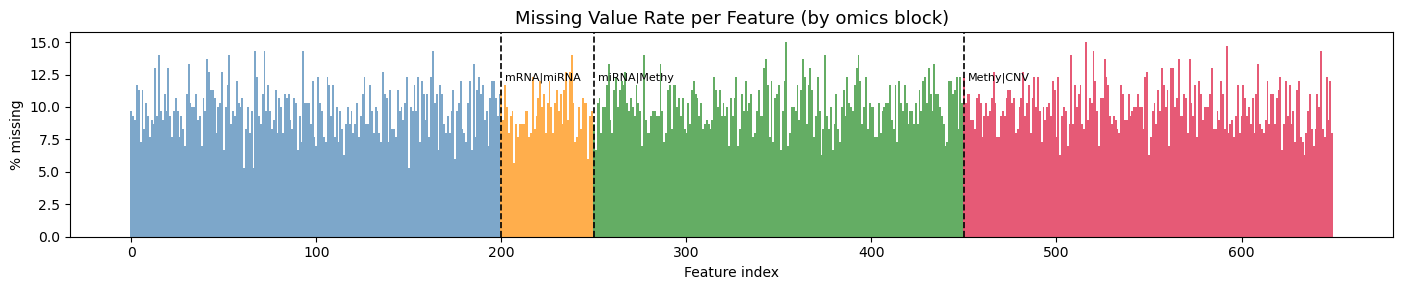

In [3]:
# Cell 3 — Visualize missing values per omics block
fig, ax = plt.subplots(figsize=(14, 3))
miss_pct = df.drop(columns=["cancer_type"]).isna().mean() * 100

colors = (["steelblue"]*200 + ["darkorange"]*50 +
          ["forestgreen"]*200 + ["crimson"]*200)
ax.bar(range(len(miss_pct)), miss_pct, color=colors, alpha=0.7, width=1.0)

# Block boundary lines
for boundary, label in zip([200, 250, 450], ["mRNA|miRNA", "miRNA|Methy", "Methy|CNV"]):
    ax.axvline(boundary, color="black", linestyle="--", linewidth=1.2)
    ax.text(boundary + 2, 12, label, fontsize=8)

ax.set_title("Missing Value Rate per Feature (by omics block)", fontsize=13)
ax.set_xlabel("Feature index")
ax.set_ylabel("% missing")
plt.tight_layout()
plt.savefig("01_missing_values.png", dpi=150)
plt.show()

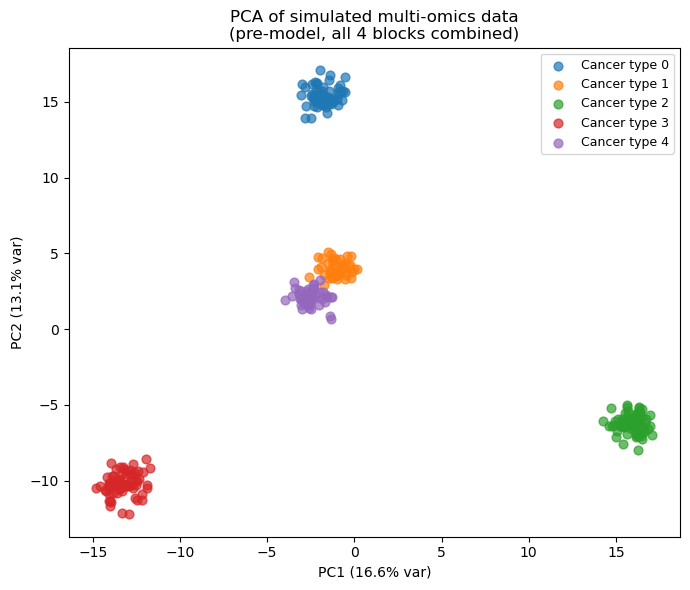

In [4]:
# Cell 4 — PCA of combined omics to see class separability
X_raw = df.drop(columns=["cancer_type"]).fillna(df.drop(columns=["cancer_type"]).median())
X_scaled = StandardScaler().fit_transform(X_raw)
y = df["cancer_type"].values

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(7, 6))
palette = sns.color_palette("tab10", n_colors=5)
for c in range(5):
    idx = y == c
    ax.scatter(X_pca[idx, 0], X_pca[idx, 1],
               label=f"Cancer type {c}",
               color=palette[c], alpha=0.7, s=40)

ax.set_title("PCA of simulated multi-omics data\n(pre-model, all 4 blocks combined)", fontsize=12)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("01_pca_overview.png", dpi=150)
plt.show()

In [5]:
# Cell 5 — Save dataset for reuse across notebooks
df.to_csv("cmob_simulated.csv", index=False)
print("Saved: cmob_simulated.csv")

Saved: cmob_simulated.csv
